In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
from sklearn import metrics
import pickle

In [2]:
data=pd.read_csv('out.csv')
data.head()

,Unnamed: 0,Gas_Type,CH4,Ar,N2,CO2,C,O,H,Shape,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Source,Time_Window,Peak_Count
0,0,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,kare,10.0,100.0,6.0,36.0,0.36,8000,kaynaksız,1,13
1,1,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,kare,10.0,100.0,6.0,36.0,0.36,8000,kaynaksız,1,13
2,2,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,kare,10.0,100.0,6.0,36.0,0.36,8000,kaynaksız,1,13
3,3,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,kare,10.0,100.0,6.0,36.0,0.36,8000,kaynaksız,1,13
4,4,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,kare,10.0,100.0,6.0,36.0,0.36,8000,kaynaksız,1,13


In [3]:
data=data.sample(frac=1)
data.drop(['Unnamed: 0','Shape','Gas_Type'],axis=1,inplace=True)
#data= data.set_index('Event')
data

,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Source,Time_Window,Peak_Count
133695,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,8.00,64.00,0.64,7000,kaynaksız,15,94
85289,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,100.00,4.00,16.00,0.16,7500,cs,1,10
124969,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,6.00,36.00,0.36,5000,kaynaksız,3,0
157,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.00,100.00,6.00,36.00,0.36,8000,kaynaksız,3,41
134589,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,8.00,64.00,0.64,6500,kaynaksız,3,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126439,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,6.00,36.00,0.36,3000,cs,15,0
52955,0.1,0.90,0.00,0.0,0.02,0.0,0.08,6.78,45.97,6.68,44.62,0.97,3500,kaynaksız,3,0
132444,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,4.00,16.00,0.16,7500,kaynaksız,15,4
101309,0.2,0.80,0.00,0.0,0.04,0.0,0.16,6.78,45.97,4.78,22.85,0.50,3000,kaynaksız,25,1


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 163800 entries, 133695 to 7102
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   CH4               163800 non-null  float64
 1   Ar                163800 non-null  float64
 2   N2                163800 non-null  float64
 3   CO2               163800 non-null  float64
 4   C                 163800 non-null  float64
 5   O                 163800 non-null  float64
 6   H                 163800 non-null  float64
 7   Detector_Size     163800 non-null  float64
 8   Detector_Area     163800 non-null  float64
 9   Cover_Size        163800 non-null  float64
 10  Cover_Area        163800 non-null  float64
 11  Cover_Area_Ratio  163800 non-null  float64
 12  Voltage           163800 non-null  int64  
 13  Source            163800 non-null  object 
 14  Time_Window       163800 non-null  int64  
 15  Peak_Count        163800 non-null  int64  
dtypes: float64(12), int64(

In [5]:
data.isnull()

,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Source,Time_Window,Peak_Count
133695,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
85289,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
124969,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
157,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
134589,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126439,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
52955,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
132444,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
101309,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [6]:
data.isnull().sum()

CH4                 0
Ar                  0
N2                  0
CO2                 0
C                   0
O                   0
H                   0
Detector_Size       0
Detector_Area       0
Cover_Size          0
Cover_Area          0
Cover_Area_Ratio    0
Voltage             0
Source              0
Time_Window         0
Peak_Count          0
dtype: int64

<Axes: >

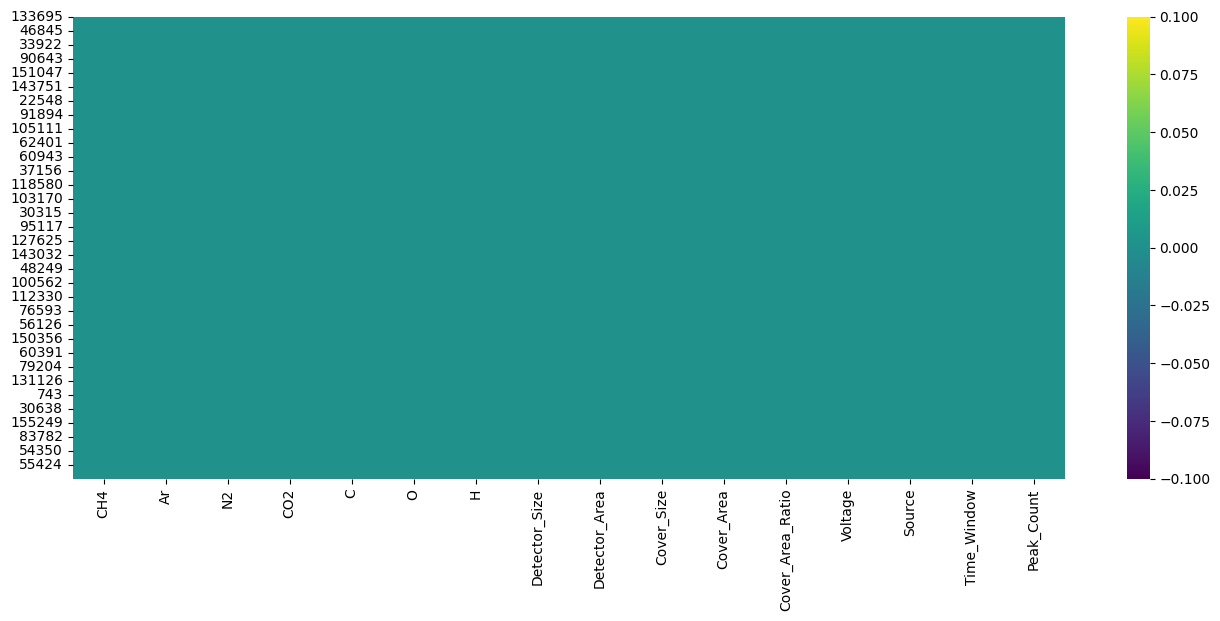

In [7]:
plt.figure(figsize=(16, 6))
sns.heatmap(data.isnull(),cmap='viridis')

In [8]:
data.dropna(inplace=True)

In [9]:
data.isnull().sum()

CH4                 0
Ar                  0
N2                  0
CO2                 0
C                   0
O                   0
H                   0
Detector_Size       0
Detector_Area       0
Cover_Size          0
Cover_Area          0
Cover_Area_Ratio    0
Voltage             0
Source              0
Time_Window         0
Peak_Count          0
dtype: int64

In [10]:
data.head()

,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Source,Time_Window,Peak_Count
133695,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.0,100.0,8.0,64.0,0.64,7000,kaynaksız,15,94
85289,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.0,100.0,4.0,16.0,0.16,7500,cs,1,10
124969,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.0,100.0,6.0,36.0,0.36,5000,kaynaksız,3,0
157,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.0,100.0,6.0,36.0,0.36,8000,kaynaksız,3,41
134589,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.0,100.0,8.0,64.0,0.64,6500,kaynaksız,3,11


In [11]:
type2=pd.get_dummies(data['Source'],drop_first=True,dtype=float)
type2

,kaynaksız
133695,1.0
85289,0.0
124969,1.0
157,1.0
134589,1.0
...,...
126439,0.0
52955,1.0
132444,1.0
101309,1.0


In [12]:
type=pd.get_dummies(data['Source'],drop_first=True,dtype=float)
type

,kaynaksız
133695,1.0
85289,0.0
124969,1.0
157,1.0
134589,1.0
...,...
126439,0.0
52955,1.0
132444,1.0
101309,1.0


In [13]:
data=pd.concat([data,type2],axis=1)
data.head()

,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Source,Time_Window,Peak_Count,kaynaksız
133695,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.0,100.0,8.0,64.0,0.64,7000,kaynaksız,15,94,1.0
85289,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.0,100.0,4.0,16.0,0.16,7500,cs,1,10,0.0
124969,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.0,100.0,6.0,36.0,0.36,5000,kaynaksız,3,0,1.0
157,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.0,100.0,6.0,36.0,0.36,8000,kaynaksız,3,41,1.0
134589,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.0,100.0,8.0,64.0,0.64,6500,kaynaksız,3,11,1.0


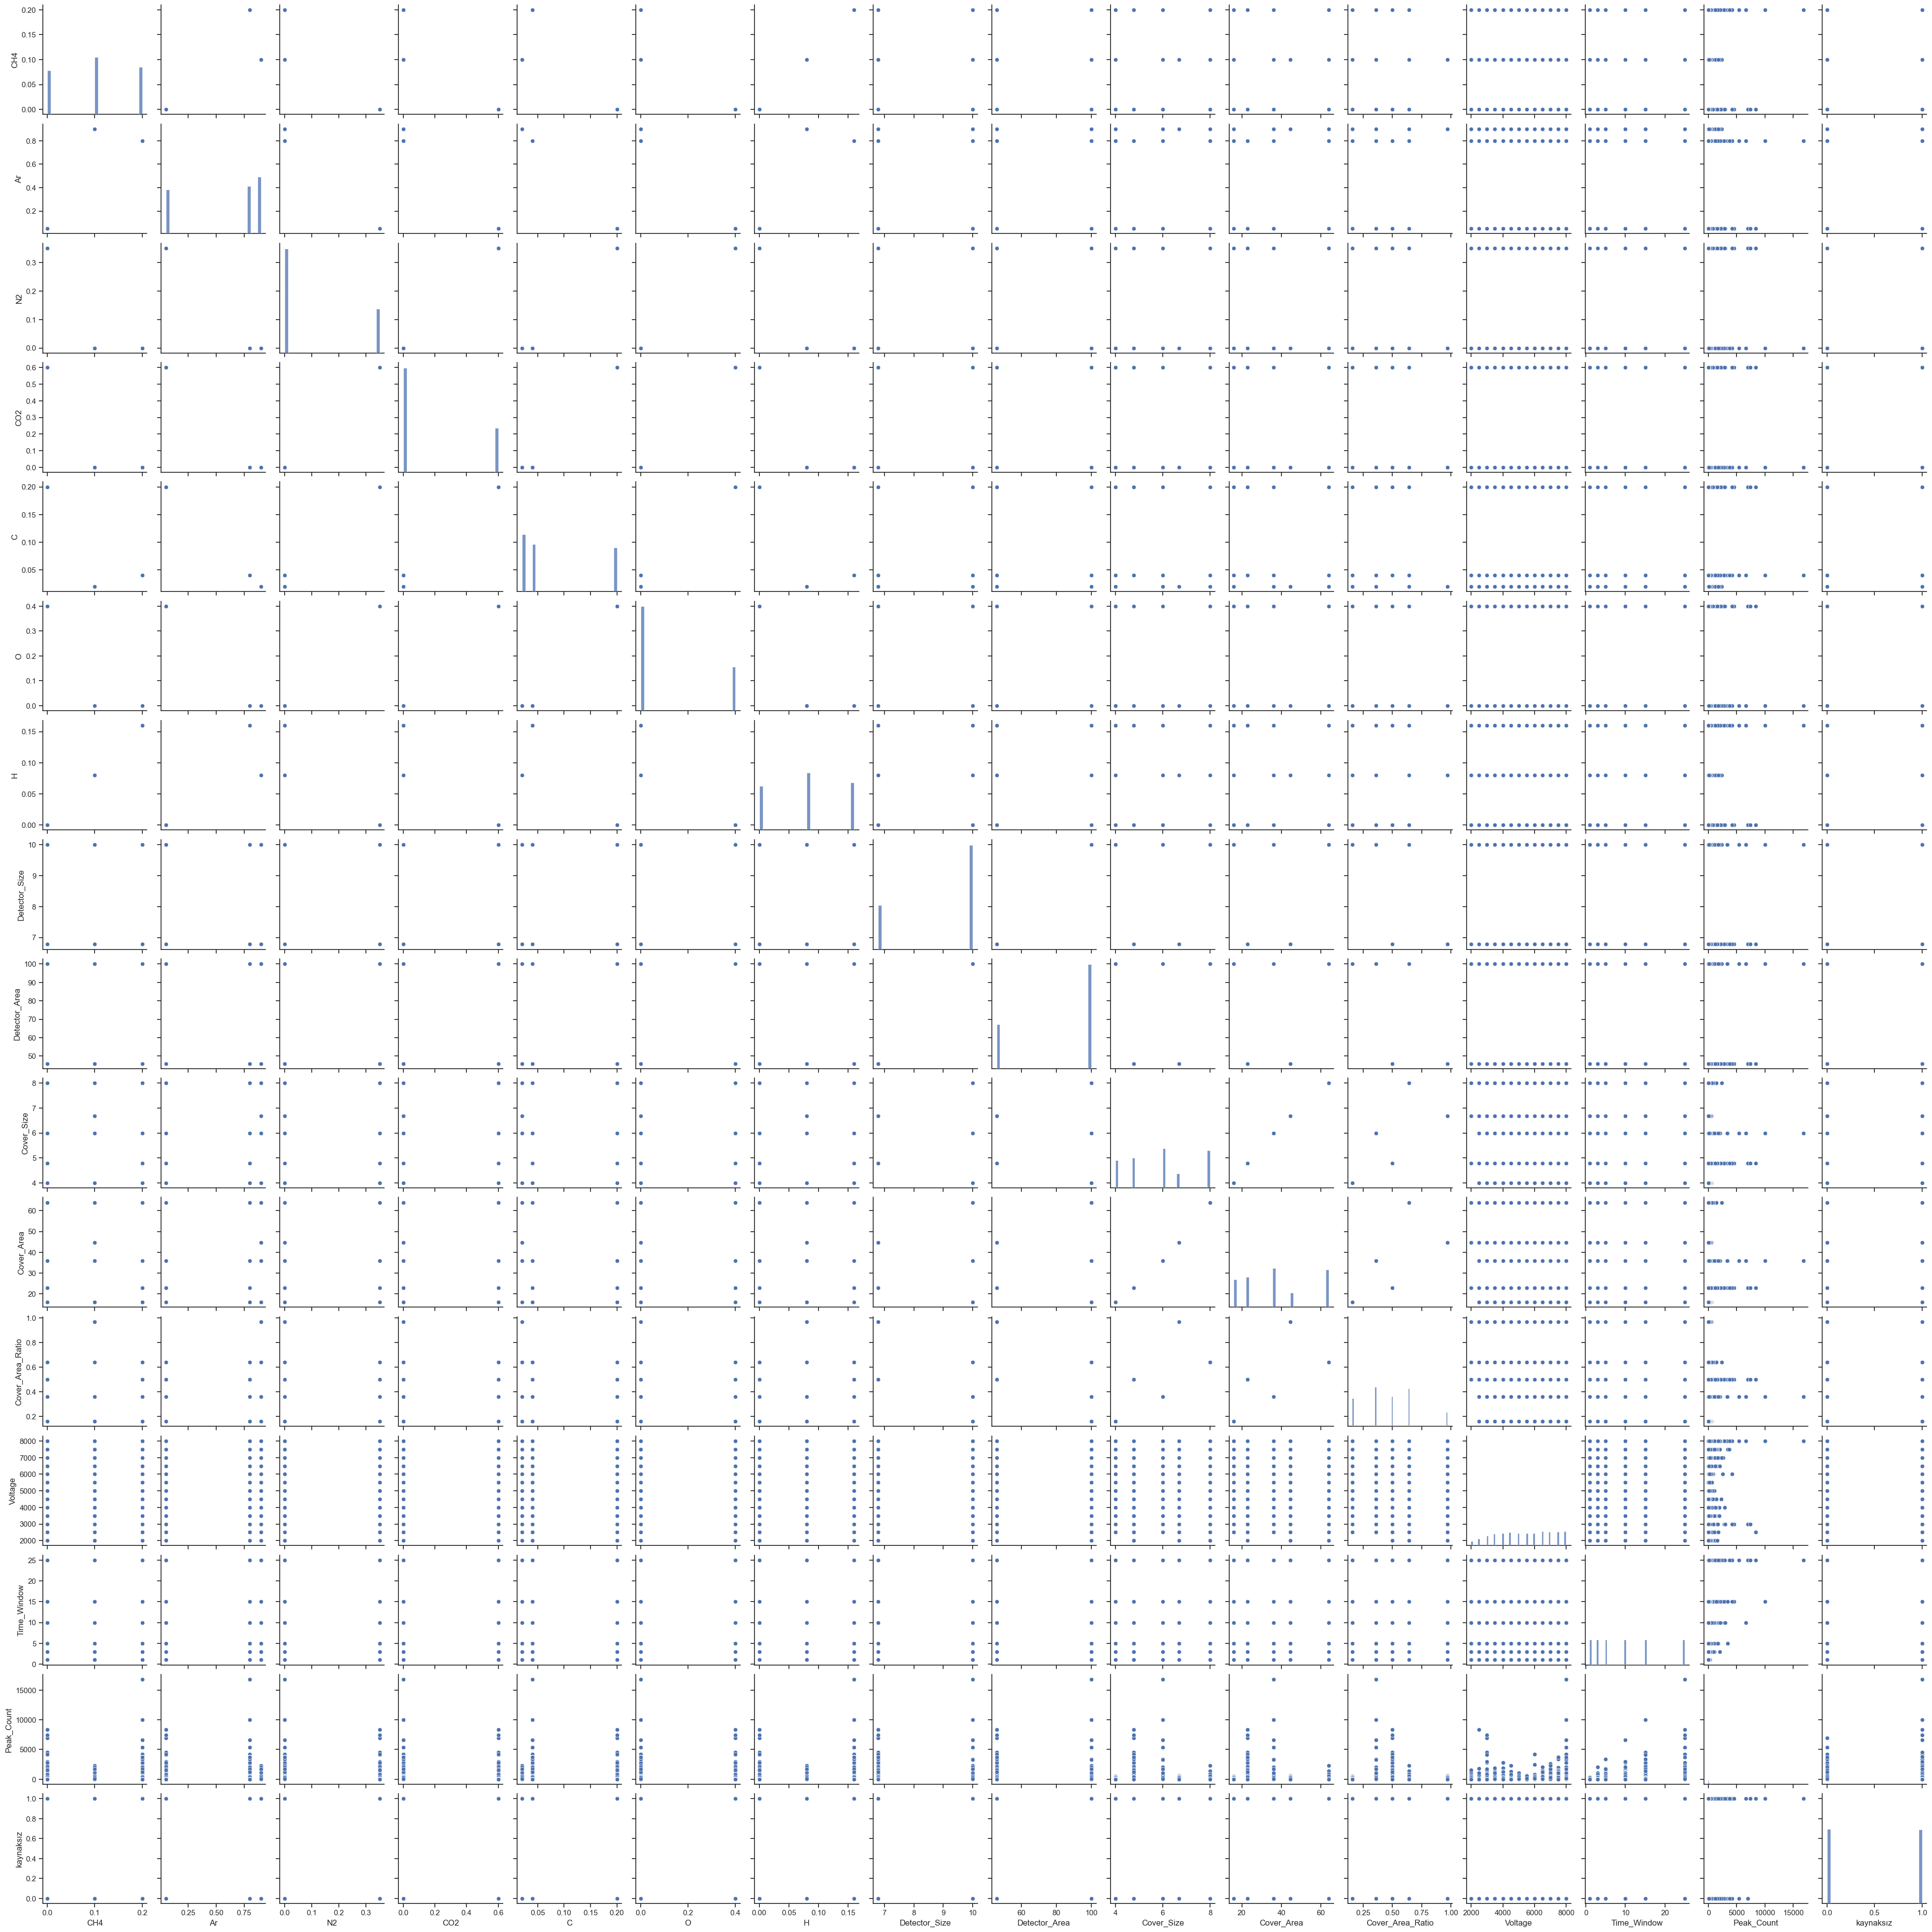

In [14]:
sns.set(style="ticks", color_codes=True)
g = sns.pairplot(data)
plt.show()

In [15]:
data.drop(['Source'],axis=1,inplace=True)
data.head()

,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Time_Window,Peak_Count,kaynaksız
133695,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.0,100.0,8.0,64.0,0.64,7000,15,94,1.0
85289,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.0,100.0,4.0,16.0,0.16,7500,1,10,0.0
124969,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.0,100.0,6.0,36.0,0.36,5000,3,0,1.0
157,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.0,100.0,6.0,36.0,0.36,8000,3,41,1.0
134589,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.0,100.0,8.0,64.0,0.64,6500,3,11,1.0


In [16]:
data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 163800 entries, 133695 to 7102
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   CH4               163800 non-null  float64
 1   Ar                163800 non-null  float64
 2   N2                163800 non-null  float64
 3   CO2               163800 non-null  float64
 4   C                 163800 non-null  float64
 5   O                 163800 non-null  float64
 6   H                 163800 non-null  float64
 7   Detector_Size     163800 non-null  float64
 8   Detector_Area     163800 non-null  float64
 9   Cover_Size        163800 non-null  float64
 10  Cover_Area        163800 non-null  float64
 11  Cover_Area_Ratio  163800 non-null  float64
 12  Voltage           163800 non-null  int64  
 13  Time_Window       163800 non-null  int64  
 14  Peak_Count        163800 non-null  int64  
 15  kaynaksız         163800 non-null  float64
dtypes: float64(13), int64(

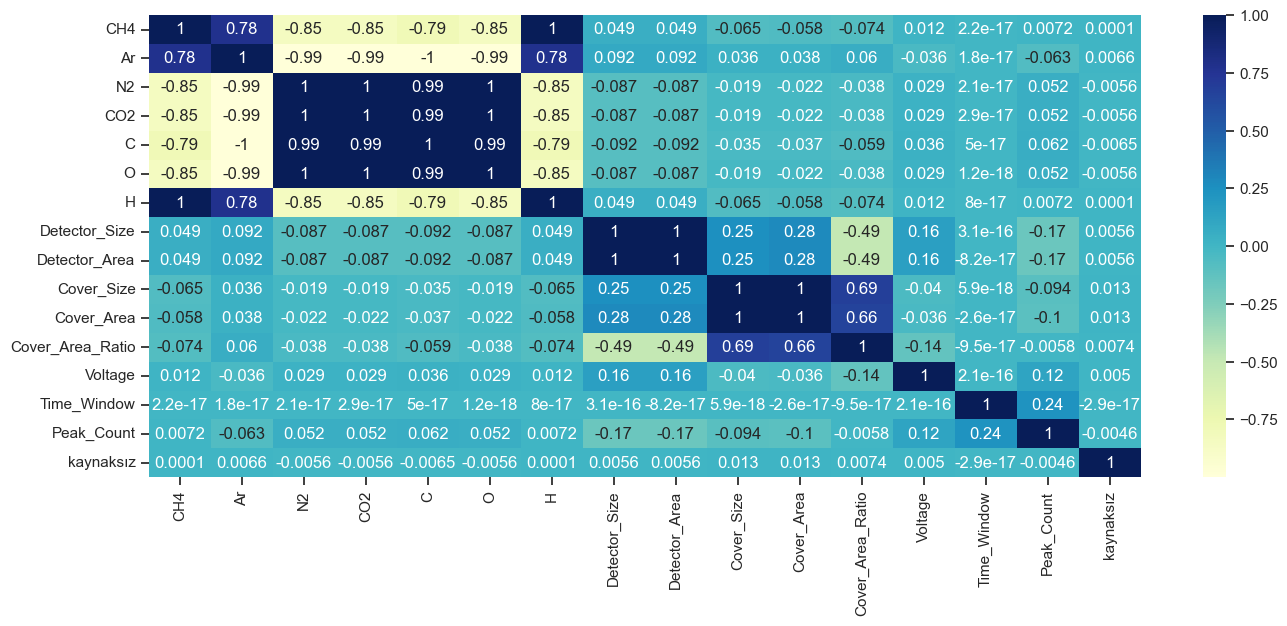

In [17]:
# creation of correlation matrix
corrM = data.corr()
plt.figure(figsize=(16, 6))
dataplot = sns.heatmap(corrM, cmap="YlGnBu", annot=True) 


In [18]:
corrM[abs(corrM['Peak_Count'])>0.1][['Peak_Count']]

,Peak_Count
Detector_Size,-0.171129
Detector_Area,-0.171129
Cover_Area,-0.102729
Voltage,0.119477
Time_Window,0.236581
Peak_Count,1.000000


In [19]:
from sklearn.model_selection import train_test_split

In [20]:
x=data.drop(['Peak_Count'],axis=1)
x=data[['Detector_Area','Cover_Area','Voltage','kaynaksız','Time_Window']]

x.head()

,Detector_Area,Cover_Area,Voltage,kaynaksız,Time_Window
133695,100.0,64.0,7000,1.0,15
85289,100.0,16.0,7500,0.0,1
124969,100.0,36.0,5000,1.0,3
157,100.0,36.0,8000,1.0,3
134589,100.0,64.0,6500,1.0,3


In [21]:
y=data['Peak_Count']
y

133695    94
85289     10
124969     0
157       41
134589    11
          ..
126439     0
52955      0
132444     4
101309     1
7102      84
Name: Peak_Count, Length: 163800, dtype: int64

In [22]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [23]:
from sklearn.linear_model import LinearRegression

In [24]:
model=LinearRegression()

In [25]:
model.fit(X_train,y_train)

LinearRegression()

In [26]:
pred=model.predict(X_test)
pred

array([ 344.76682488,  500.98057595,  335.73392446, ...,   14.50276806,
       -130.8484632 ,  -93.81328506])

In [27]:
y_test

13020     349
149115    808
106811    131
122718     75
37860      10
         ... 
123221      0
21115      11
122188      0
43304      53
35037      60
Name: Peak_Count, Length: 32760, dtype: int64

In [28]:
X_test

,Detector_Area,Cover_Area,Voltage,kaynaksız,Time_Window
13020,100.00,36.00,7000,0.0,15
149115,45.97,22.85,6000,0.0,10
106811,45.97,22.85,6500,0.0,1
122718,100.00,36.00,8000,1.0,10
37860,100.00,64.00,6000,1.0,1
...,...,...,...,...,...
123221,100.00,36.00,5000,0.0,5
21115,100.00,16.00,4000,1.0,3
122188,100.00,36.00,3500,0.0,10
43304,100.00,64.00,4500,0.0,3


In [29]:
model.score(X_test, y_test)

0.09966532839676967

In [30]:
pred

array([ 344.76682488,  500.98057595,  335.73392446, ...,   14.50276806,
       -130.8484632 ,  -93.81328506])

In [31]:
y_test

13020     349
149115    808
106811    131
122718     75
37860      10
         ... 
123221      0
21115      11
122188      0
43304      53
35037      60
Name: Peak_Count, Length: 32760, dtype: int64

In [32]:
indexes = X_test.index.values
len(indexes)

32760

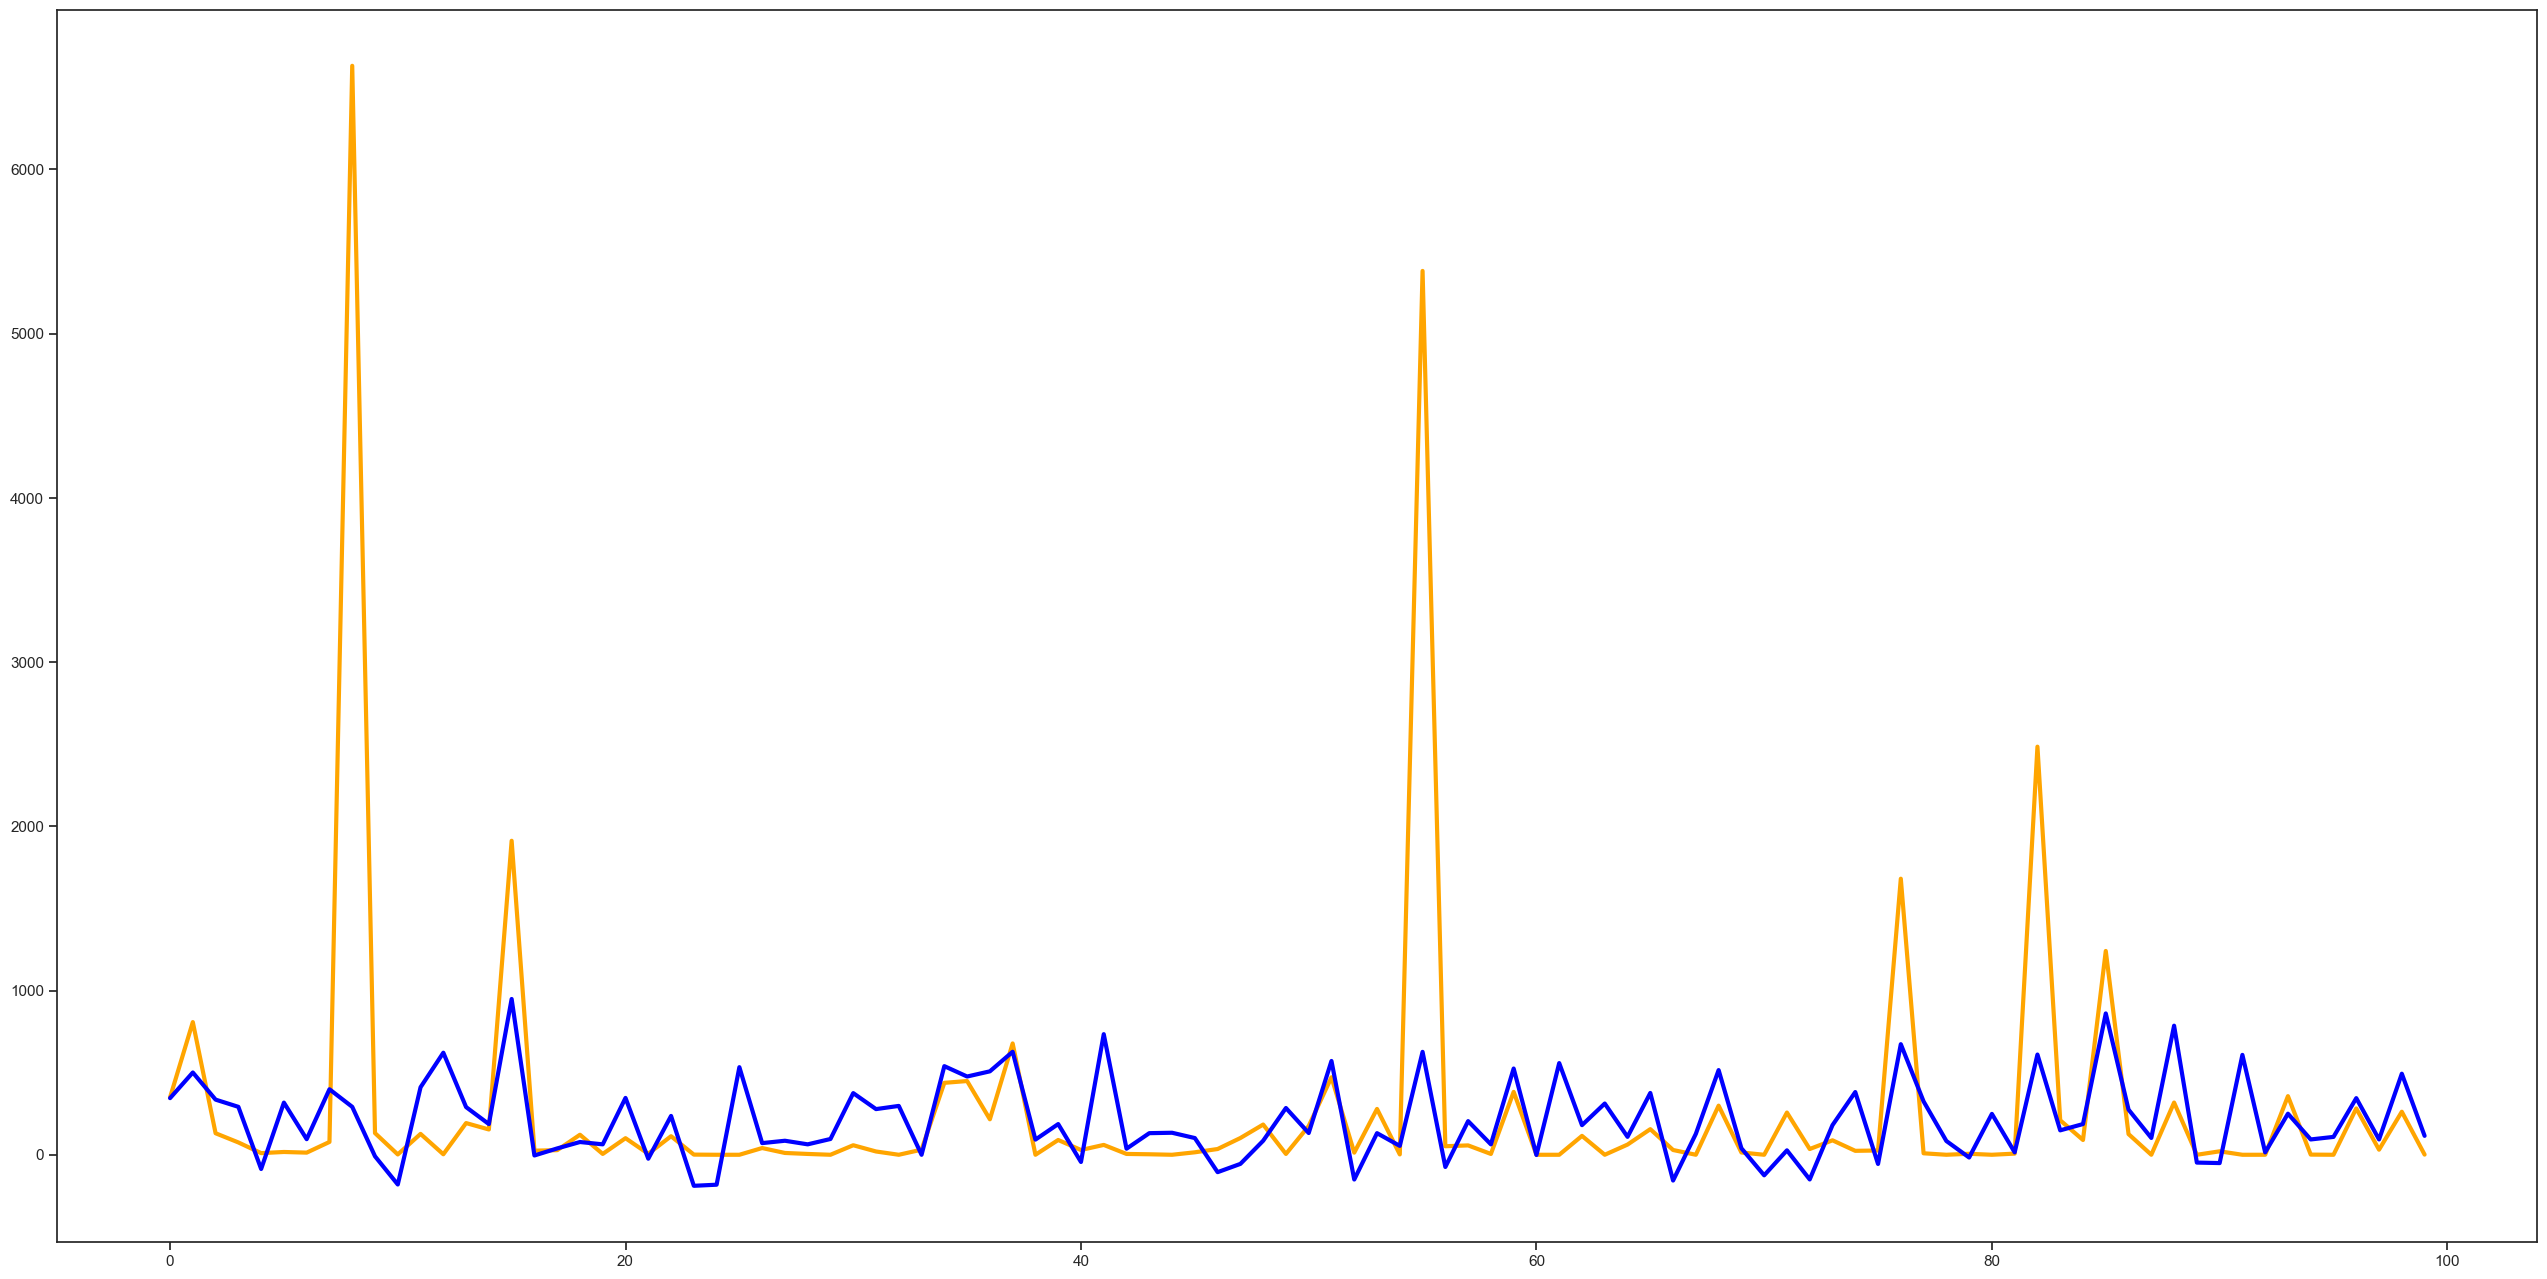

In [33]:
plt.figure(figsize=(32, 16))
plt.plot(range(0,len(indexes))[:100],y_test[:100], color="orange", linewidth=3)
plt.plot(range(0,len(indexes))[:100],pred[:100], color="blue", linewidth=3)
plt.show()